# NGS variant calling workflow

<div style="background-color: PaleTurquoise; padding: 10px;">
    
This notebook contains a simple SNP calling workflow.

Please run and explore this workflow.

Areas with questions about QC are highlighted in yellow

</div>

## Case

Two exome sequencing samples of a T-Cell Acute Lymphoblastic Leukemia patient. 

One sample (`TLE66_T`) is of tumor, one healthy control sample  (`TLE66_N`)

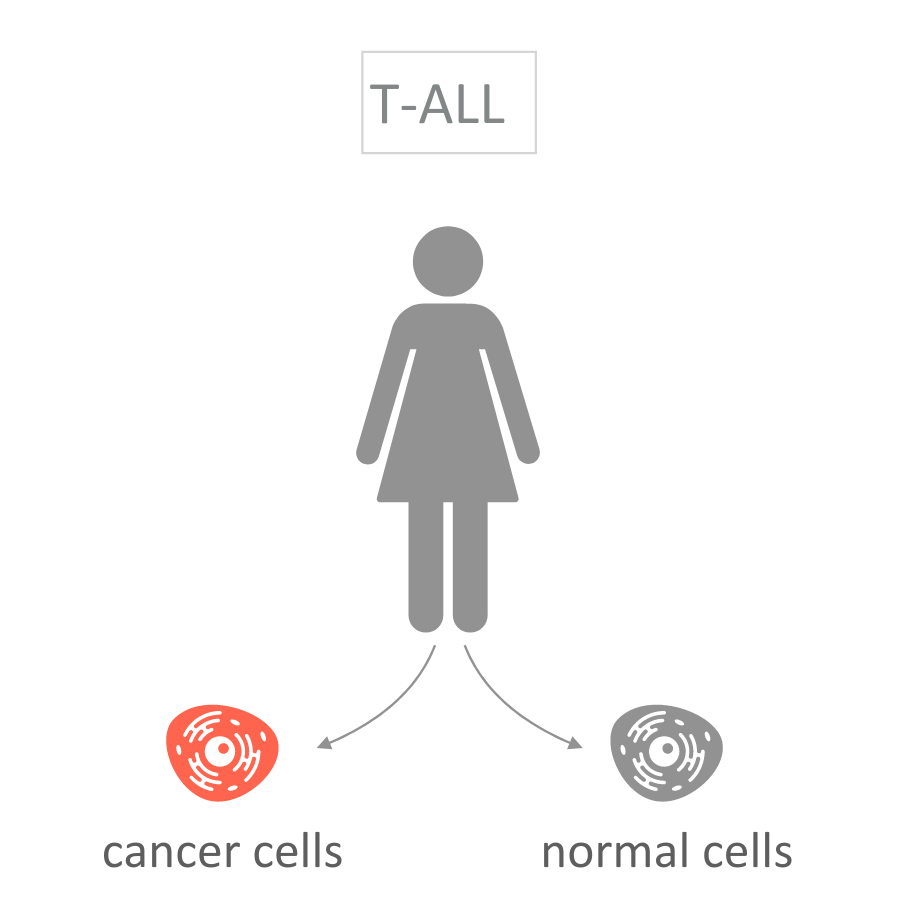

Goal: process the raw fastq, call & annotate SNPs.

We want to ultimately find interesting variants that may be causal to the T-ALL.

## Preparation

In [1]:
import os

# Force Jupyter to add the course tools to its PATH
course_bin = "/lustre1/project/stg_00079/teaching/I0U19a_conda_2026/bin/"
os.environ['PATH'] = f"{course_bin}:{os.environ['PATH']}"

print("Environment PATH successfully updated!")

Environment PATH successfully updated!


In [2]:
%%sh
echo $VSC_DATA

/data/leuven/381/vsc38184


The cleanest way to work with notebooks is to first create a folder on your server (VSC). For example:

    mkdir $VSC_DATA/variant_calling_manual

- You can do this in the jupyter interface
- Upload your notebook to this folder
- Navigate to this folder from jupyter
- Open the notebook

This ensures you are always working from the correct location. If you did not do this, please shutdown this notebook and do this.

If you do not do this, you are in the wrong folder upon a notebook crash, or when you forget to cd into your workfolder.

In [3]:
%%sh
# make sure we add our conda environment to the path
# there are also a number of command line tools installed
# You need to do this every time you need to use our conda env.

export PATH=/lustre1/project/stg_00079/teaching/I0U19a_conda_2026/bin/:$PATH

In [4]:
# ensure we are using the correct environment - test with bwa
!which bwa

/lustre1/project/stg_00079/teaching/I0U19a_conda_2026/bin/bwa


In [5]:
%%sh
# create a scratch folder! - Important to check you are working in the correct scratch folder for subsequent workœ
# Make sure you use absolute paths as much as possible - relative paths can give unexpected results.
# image running (`mkdir variant_calling_manual ; cd variant_calling_manual`) twice in a row.

mkdir -p $VSC_SCRATCH/variant_calling_manual
cd $VSC_SCRATCH/variant_calling_manual
pwd
ls

/scratch/leuven/381/vsc38184/variant_calling_manual


In [6]:
%%sh
# We will be using the genome sequence & index a few times - 
# So I'll use an environment variable

# Note - we are definitely using hg19 for this course.

# To keep memory requirements in check we're using a truncated database with just chromosome 9
DB=/staging/leuven/stg_00079/teaching/hg38_9/chr9.fa

In [7]:
ls -lh $DB

total 70M
-rw-r--r-- 1 vsc38184 vsc38184 1.7M May 22 20:43 annotated_snps.vcf
-rw-r--r-- 1 vsc38184 vsc38184 555K May 22 20:43 clean_snps.vcf
drwxr-xr-x 2 vsc38184 vsc38184 4.0K May 22 12:23 fastqc_output/
-rw-r----- 1 vsc38184 vsc38184 324K May 22 12:59 manual_snp_calling_workflow.ipynb
-rw-r--r-- 1 vsc38184 vsc38184 960K May 22 20:43 raw_snps.vcf
-rw-r----- 1 vsc38184 vsc38184    0 May  4 19:49 README.md
-rw-r----- 1 vsc38184 vsc38184 1.3K May 21 20:22 run_notebook.sh
-rw-r--r-- 1 vsc38184 vsc38184  43K May 22 20:43 snpEff_genes.txt
-rw-r--r-- 1 vsc38184 vsc38184 226K May 22 20:43 snpEff_summary.html
-rw-r--r-- 1 vsc38184 vsc38184  35M May 22 20:42 TLE66_N.bam
-rw-r--r-- 1 vsc38184 vsc38184  79K May 22 20:43 TLE66_N.bam.bai
lrwxrwxrwx 1 vsc38184 vsc38184   68 May 22 20:42 TLE66_N.fastq -> /staging/leuven/stg_00079/teaching/data_manual_snpcall/TLE66_N.fastq
-rw-r--r-- 1 vsc38184 vsc38184  31M May 22 20:43 TLE66_T.bam
-rw-r--r-- 1 vsc38184 vsc38184  78K May 22 20:43 TLE66_T.bam.bai
lrw

<div style="background-color: khaki; padding: 10px;">

## Prepare

* What are the version numbers of all tools used in this notebook. Get it from the tools!
* FastQC v0.12.1
* Version: 0.7.19-r1273
* samtools 1.23
* bcftools 1.23
* SnpEff	5.4a	2025-11-25
</div>

In [8]:
%%bash
fastqc --version
bwa 2>&1 | grep Version
samtools --version | head -n 1
bcftools --version | head -n 1
java -jar /lustre1/project/stg_00079/teaching/I0U19a_conda_2026/share/snpeff-5.4.0a-0/snpEff.jar -version

FastQC v0.12.1
Version: 0.7.19-r1273
samtools 1.23
bcftools 1.23


SnpEff	5.4a	2025-11-25


## ToolsVersion Numbers

FastQC v0.12.1
Version: 0.7.19-r1273
samtools 1.23
bcftools 1.23
SnpEff	5.4a	2025-11-25

In [9]:
%%sh
# Create a symlink to VSC_SCRATCH from $VSC_DATA -
# so that you can inspect your data using the jupyter file browser
ln -sf $VSC_SCRATCH $VSC_DATA/scratch 

In [10]:
%%sh
ln -sf /staging/leuven/stg_00079/teaching/data_manual_snpcall/*.fastq .
ls -l

total 71164
-rw-r--r-- 1 vsc38184 vsc38184  1775439 May 22 20:43 annotated_snps.vcf
-rw-r--r-- 1 vsc38184 vsc38184   567832 May 22 20:43 clean_snps.vcf
drwxr-xr-x 2 vsc38184 vsc38184     4096 May 22 12:23 fastqc_output
-rw-r----- 1 vsc38184 vsc38184   331459 May 22 12:59 manual_snp_calling_workflow.ipynb
-rw-r--r-- 1 vsc38184 vsc38184   982232 May 22 20:43 raw_snps.vcf
-rw-r----- 1 vsc38184 vsc38184        0 May  4 19:49 README.md
-rw-r----- 1 vsc38184 vsc38184     1284 May 21 20:22 run_notebook.sh
-rw-r--r-- 1 vsc38184 vsc38184    43281 May 22 20:43 snpEff_genes.txt
-rw-r--r-- 1 vsc38184 vsc38184   230498 May 22 20:43 snpEff_summary.html
-rw-r--r-- 1 vsc38184 vsc38184 36321020 May 22 20:42 TLE66_N.bam
-rw-r--r-- 1 vsc38184 vsc38184    80208 May 22 20:43 TLE66_N.bam.bai
lrwxrwxrwx 1 vsc38184 vsc38184       68 May 22 20:45 TLE66_N.fastq -> /staging/leuven/stg_00079/teaching/data_manual_snpcall/TLE66_N.fastq
-rw-r--r-- 1 vsc38184 vsc38184 32427184 May 22 20:43 TLE66_T.bam
-rw-r--r-- 1 vs

The `sha256` checksums of these files are supposed to be:

    5ad4bb2f5bd5f6e430b7ab2fff0a164255d4e608363104a75142b6c5a032ddf9  TLE66_N.fastq
    cd9d41d1c0b59a4819fa58007ef796c543b1a7346cb11cceb71ad02d9e2b2cfe  TLE66_T.fastq


<div style="background-color: khaki; padding: 10px;">

## Raw data Quality Control

* Do the checksums match?
* Yes as confirmed from sha256sum *.fastq

* Do the raw files look like fastq?
* Yes, they look like fastq files as they have header @num, sequence, separator, quality scores


* Do they have a reasonable number of reads?

* Yes, they have reasonable number of reads [Normal Sample (TLE66_N): 540,624 reads, Tumor Sample (TLE66_T): 477,888 reads]
 
 
</div>

In [11]:
%%bash
head -n 4 TLE66_N.fastq
echo "Line counts (divide by 4 for read counts):"
wc -l *.fastq
sha256sum *.fastq

@1121358
TGAATCTGGGAGGCGGAGGTTGCAGTGAGAGTGAGGCGAGATCTCGCCATTGCACTCCAGCCGGGGTGACAAGAG
+
<D<?><DIBB??BF;@;AB@CHG<A?F<@>@;F>>6?8??@@BD,;FF=?DIBD?F;EDAGE8BBC9G?FEBB>@
Line counts (divide by 4 for read counts):
  2162496 TLE66_N.fastq
  1911552 TLE66_T.fastq
  4074048 total


5ad4bb2f5bd5f6e430b7ab2fff0a164255d4e608363104a75142b6c5a032ddf9  TLE66_N.fastq
cd9d41d1c0b59a4819fa58007ef796c543b1a7346cb11cceb71ad02d9e2b2cfe  TLE66_T.fastq


* Yes, they look as fastq files as they have header @num, sequence, separator, quality scores 
* Yes, they have reasonable number of reads [Normal Sample (TLE66_N): 540,624 reads, Tumor Sample (TLE66_T): 477,888 reads]

* Yes as confirmed from sha256sum *.fastq

In [12]:
# you can get help using
!fastqc --help


            FastQC - A high throughput sequence QC analysis tool

SYNOPSIS

	fastqc seqfile1 seqfile2 .. seqfileN

    fastqc [-o output dir] [--(no)extract] [-f fastq|bam|sam] 
           [-c contaminant file] seqfile1 .. seqfileN

DESCRIPTION

    FastQC reads a set of sequence files and produces from each one a quality
    control report consisting of a number of different modules, each one of 
    which will help to identify a different potential type of problem in your
    data.
    
    If no files to process are specified on the command line then the program
    will start as an interactive graphical application.  If files are provided
    on the command line then the program will run with no user interaction
    required.  In this mode it is suitable for inclusion into a standardised
    analysis pipeline.
    
    The options for the program as as follows:
    
    -h --help       Print this help file and exit
    
    -v --version    Print the version of the program and exit

In [13]:
%%sh
# Run fastqc - could take a minute or two
mkdir -p fastqc_output
fastqc *.fastq -o fastqc_output

null
null


Started analysis of TLE66_N.fastq
Approx 5% complete for TLE66_N.fastq
Approx 10% complete for TLE66_N.fastq
Approx 15% complete for TLE66_N.fastq
Approx 20% complete for TLE66_N.fastq
Approx 25% complete for TLE66_N.fastq
Approx 30% complete for TLE66_N.fastq
Approx 35% complete for TLE66_N.fastq
Approx 40% complete for TLE66_N.fastq
Approx 45% complete for TLE66_N.fastq
Approx 50% complete for TLE66_N.fastq
Approx 55% complete for TLE66_N.fastq
Approx 60% complete for TLE66_N.fastq
Approx 65% complete for TLE66_N.fastq
Approx 70% complete for TLE66_N.fastq
Approx 75% complete for TLE66_N.fastq
Approx 80% complete for TLE66_N.fastq
Approx 85% complete for TLE66_N.fastq
Approx 90% complete for TLE66_N.fastq
Approx 95% complete for TLE66_N.fastq


Analysis complete for TLE66_N.fastq


Started analysis of TLE66_T.fastq
Approx 5% complete for TLE66_T.fastq
Approx 10% complete for TLE66_T.fastq
Approx 15% complete for TLE66_T.fastq
Approx 20% complete for TLE66_T.fastq
Approx 25% complete for TLE66_T.fastq
Approx 30% complete for TLE66_T.fastq
Approx 35% complete for TLE66_T.fastq
Approx 40% complete for TLE66_T.fastq
Approx 45% complete for TLE66_T.fastq
Approx 50% complete for TLE66_T.fastq
Approx 55% complete for TLE66_T.fastq
Approx 60% complete for TLE66_T.fastq
Approx 65% complete for TLE66_T.fastq
Approx 70% complete for TLE66_T.fastq
Approx 75% complete for TLE66_T.fastq
Approx 80% complete for TLE66_T.fastq
Approx 85% complete for TLE66_T.fastq
Approx 90% complete for TLE66_T.fastq
Approx 95% complete for TLE66_T.fastq


Analysis complete for TLE66_T.fastq


Back in your jupyter browser you can see the html & zip outputs

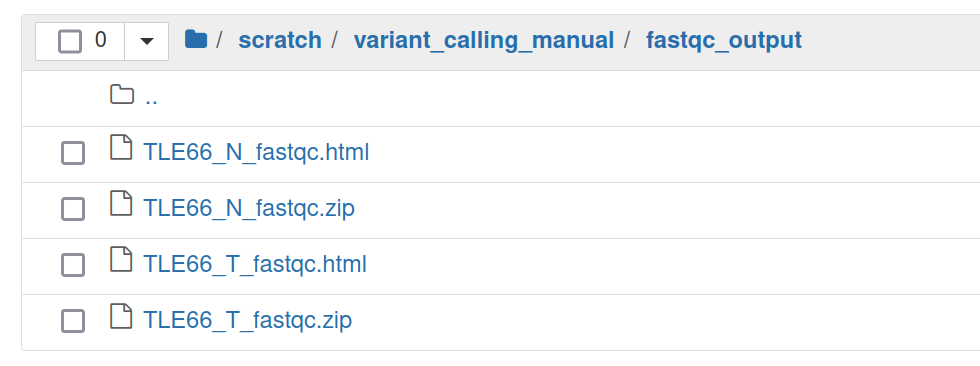


<div style="background-color: khaki; padding: 10px;">

## Fastq data Quality Control

* Is the quality ok?


* Yes, the quality is good. Looking at the FastQC report, specifically the "Per base sequence quality" plot, the majority of the sequence lengths have quality scores that remain in the green zone (Phred score > 28). This indicates a high base call accuracy (typically >99.9% accuracy).

* How is the quality score encoded? Do you need to take this into account?
* The quality scores are encoded using ASCII characters representing Phred quality scores, specifically Phred+33 (the standard for Sanger and modern Illumina 1.8+ data).
Historically it was very important to address the encoding of quality score because older Illumina machines used a different encoding (Phred+64). If a bioinformatic tool assumes the wrong encoding, it will completely miscalculate the quality of your data, leading to false variant calls or discarding perfectly good reads. Fortunately, most modern tools (like FastQC and BWA) now automatically detect that it is Phred+33 and handle it for you.
 
</div>

## Align the reads

We will be using `bwa mem`. Get help by running without arguments

In [14]:
%%bash
bwa mem || true


Usage: bwa mem [options] <idxbase> <in1.fq> [in2.fq]

Algorithm options:

       -t INT        number of threads [1]
       -k INT        minimum seed length [19]
       -w INT        band width for banded alignment [100]
       -d INT        off-diagonal X-dropoff [100]
       -r FLOAT      look for internal seeds inside a seed longer than {-k} * FLOAT [1.5]
       -y INT        seed occurrence for the 3rd round seeding [20]
       -c INT        skip seeds with more than INT occurrences [500]
       -D FLOAT      drop chains shorter than FLOAT fraction of the longest overlapping chain [0.50]
       -W INT        discard a chain if seeded bases shorter than INT [0]
       -m INT        perform at most INT rounds of mate rescues for each read [50]
       -S            skip mate rescue
       -P            skip pairing; mate rescue performed unless -S also in use

Scoring options:

       -A INT        score for a sequence match, which scales options -TdBOELU unless overridden [1]
     

In [15]:
%%bash
echo ${DB}

In [16]:
%%bash
DB="/staging/leuven/stg_00079/teaching/hg38_9/chr9.fa"
bwa mem ${DB} TLE66_N.fastq | samtools sort -o TLE66_N.bam -

[M::bwa_idx_load_from_disk] read 0 ALT contigs
[M::process] read 133334 sequences (10000050 bp)...
[M::process] read 133334 sequences (10000050 bp)...
[M::mem_process_seqs] Processed 133334 reads in 3.229 CPU sec, 3.155 real sec
[M::process] read 133334 sequences (10000050 bp)...
[M::mem_process_seqs] Processed 133334 reads in 3.450 CPU sec, 3.321 real sec
[M::process] read 133334 sequences (10000050 bp)...
[M::mem_process_seqs] Processed 133334 reads in 3.934 CPU sec, 3.820 real sec
[M::process] read 7288 sequences (546600 bp)...
[M::mem_process_seqs] Processed 133334 reads in 4.382 CPU sec, 4.313 real sec
[M::mem_process_seqs] Processed 7288 reads in 0.382 CPU sec, 0.306 real sec
[main] Version: 0.7.19-r1273
[main] CMD: bwa mem /staging/leuven/stg_00079/teaching/hg38_9/chr9.fa TLE66_N.fastq
[main] Real time: 15.106 sec; CPU: 15.568 sec


In [17]:
%%bash
DB="/staging/leuven/stg_00079/teaching/hg38_9/chr9.fa"
bwa mem ${DB} TLE66_T.fastq | samtools sort - > TLE66_T.bam

[M::bwa_idx_load_from_disk] read 0 ALT contigs


[M::process] read 133334 sequences (10000050 bp)...
[M::process] read 133334 sequences (10000050 bp)...
[M::mem_process_seqs] Processed 133334 reads in 3.037 CPU sec, 2.964 real sec
[M::process] read 133334 sequences (10000050 bp)...
[M::mem_process_seqs] Processed 133334 reads in 3.402 CPU sec, 3.297 real sec
[M::process] read 77886 sequences (5841450 bp)...
[M::mem_process_seqs] Processed 133334 reads in 3.464 CPU sec, 3.355 real sec
[M::mem_process_seqs] Processed 77886 reads in 3.129 CPU sec, 3.066 real sec
[main] Version: 0.7.19-r1273
[main] CMD: bwa mem /staging/leuven/stg_00079/teaching/hg38_9/chr9.fa TLE66_T.fastq
[main] Real time: 12.902 sec; CPU: 13.248 sec


In [18]:
%%sh
# create indici
samtools index TLE66_N.bam
samtools index TLE66_T.bam

In [19]:
%%sh
pwd
ls -l

/lustre1/scratch/381/vsc38184/large_omics/r1097686_Pietro_Maria_Zangrando/010_manual_snpcall
total 71164
-rw-r--r-- 1 vsc38184 vsc38184  1775439 May 22 20:43 annotated_snps.vcf
-rw-r--r-- 1 vsc38184 vsc38184   567832 May 22 20:43 clean_snps.vcf
drwxr-xr-x 2 vsc38184 vsc38184     4096 May 22 12:23 fastqc_output
-rw-r----- 1 vsc38184 vsc38184   331459 May 22 12:59 manual_snp_calling_workflow.ipynb
-rw-r--r-- 1 vsc38184 vsc38184   982232 May 22 20:43 raw_snps.vcf
-rw-r----- 1 vsc38184 vsc38184        0 May  4 19:49 README.md
-rw-r----- 1 vsc38184 vsc38184     1284 May 21 20:22 run_notebook.sh
-rw-r--r-- 1 vsc38184 vsc38184    43281 May 22 20:43 snpEff_genes.txt
-rw-r--r-- 1 vsc38184 vsc38184   230498 May 22 20:43 snpEff_summary.html
-rw-r--r-- 1 vsc38184 vsc38184 36321020 May 22 20:46 TLE66_N.bam
-rw-r--r-- 1 vsc38184 vsc38184    80208 May 22 20:46 TLE66_N.bam.bai
lrwxrwxrwx 1 vsc38184 vsc38184       68 May 22 20:45 TLE66_N.fastq -> /staging/leuven/stg_00079/teaching/data_manual_snpcall/T

<div style="background-color: khaki; padding: 10px;">

## BAM  Quality control

* Did all tools finish without error?
* Yes, all tools finished successfully without throwing any errors
* Is the header correct? (Use `samtools view -H`)
* Yes, the header is properly formatted. It contains the @HD tag (showing the format version 1.5), the @SQ tag (showing the reference chromosome chr9 and its length), and the @PG tags (documenting the exact bwa and samtools commands used to generate the file).
* Do the files look like BAM? (Use `samtools view ... | head`)
* Yes. The samtools view output shows standard SAM-formatted alignment lines, including the read name, bitwise flag (e.g., 16 or 0), chromosome name (chr9), mapping position, CIGAR string (e.g., 75M), the DNA sequence, and the quality scores.
* To which chromosomes to the reads map? (Use `samtools idxstats`) What do you expect? 
* The reads map almost entirely to chr9 (540,563 reads), with a tiny fraction (98 reads) remaining unmapped. This is exactly what we expect, as the reference genome database we used (chr9.fa) only contained chromosome 9.
* How many & what percentage of the reads map properly? (Use `samtools flagstat`)
* 540,526 primary reads mapped successfully, which is 99.98% of the total reads. This is an excellent alignment rate.
* Download the bam & bai files to disk & visualize in [IGV](https://igv.org/app/). Copy/paste a screenshot.
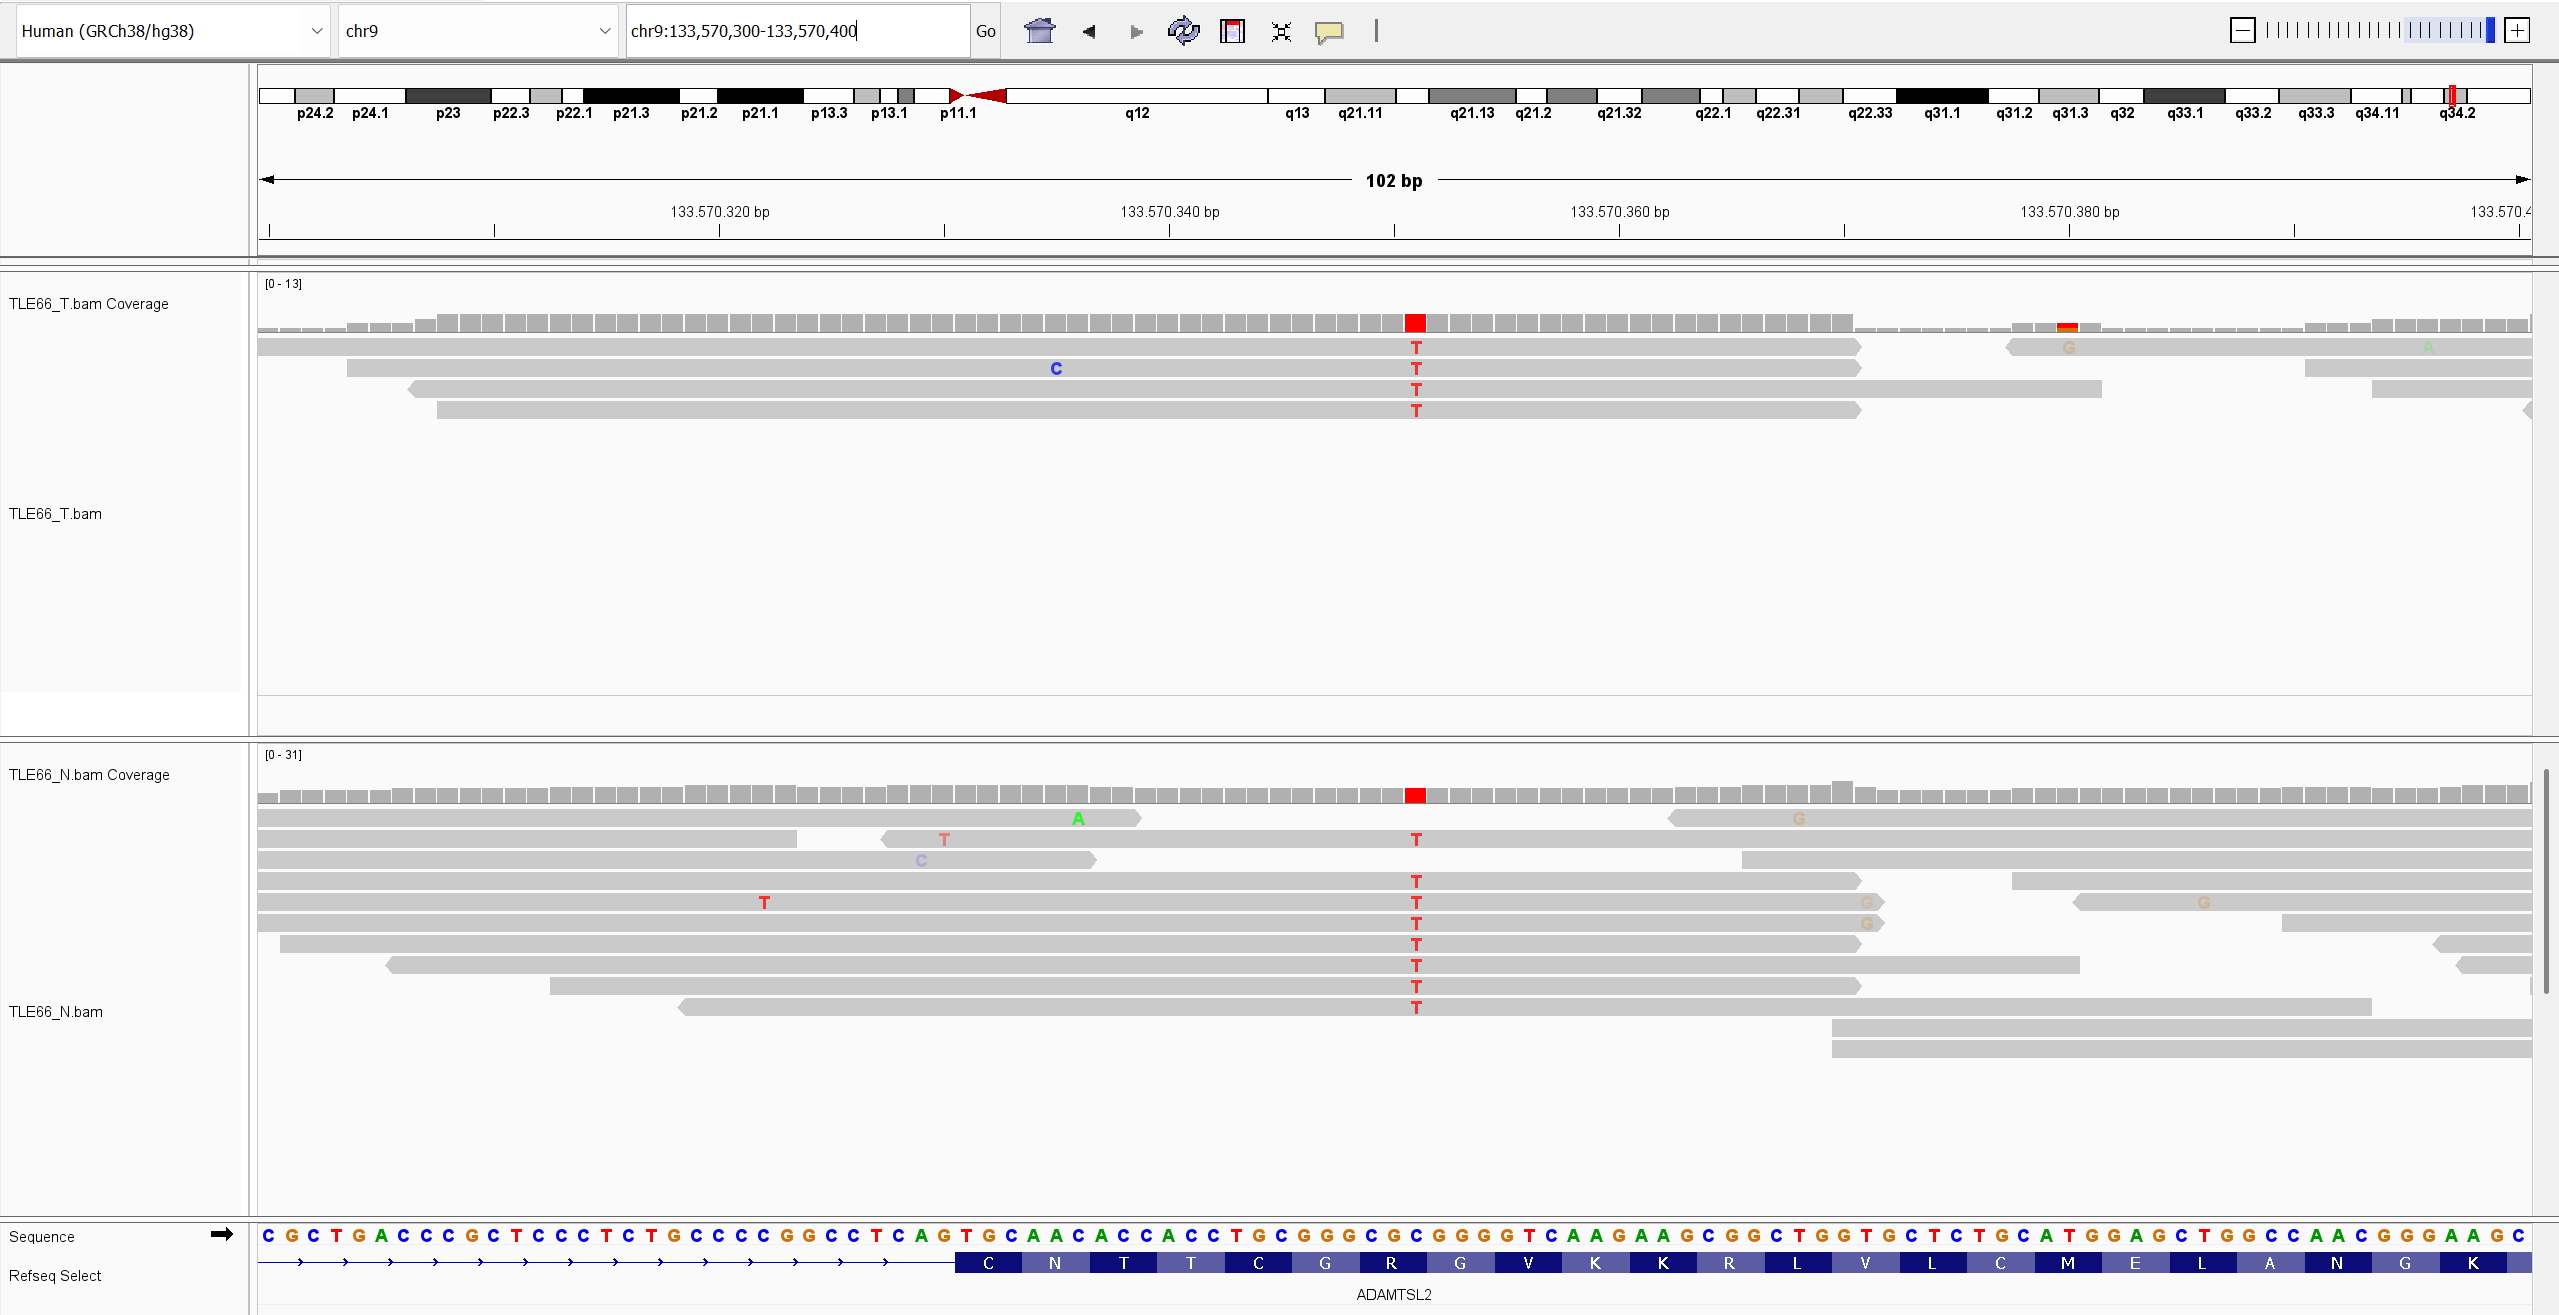
</div>

In [20]:
%%bash
echo "--- HEADER CHECK ---"
samtools view -H TLE66_N.bam | head -n 5

echo -e "\n--- BAM FORMAT CHECK ---"
samtools view TLE66_N.bam | head -n 3

echo -e "\n--- CHROMOSOME MAPPING (IDXSTATS) ---"
samtools idxstats TLE66_N.bam

echo -e "\n--- MAPPING PERCENTAGE (FLAGSTAT) ---"
samtools flagstat TLE66_N.bam

--- HEADER CHECK ---
@HD	VN:1.5	SO:coordinate
@SQ	SN:chr9	LN:138394717
@PG	ID:bwa	PN:bwa	VN:0.7.19-r1273	CL:bwa mem /staging/leuven/stg_00079/teaching/hg38_9/chr9.fa TLE66_N.fastq
@PG	ID:samtools	PN:samtools	PP:bwa	VN:1.23	CL:samtools sort -o TLE66_N.bam -
@PG	ID:samtools.1	PN:samtools	PP:samtools	VN:1.23	CL:samtools view -H TLE66_N.bam

--- BAM FORMAT CHECK ---
FCB06B3ABXX:8:2108:12853:63847	16	chr9	150174	0	75M	*	0	0	TGGAGTGCAGTGGTGCGATCTCAGCTCACTGCAAGCTCCGCCTCCCGGGTTCACGCCATTCTCCTGCCTCAGCCT	GGDGI/HJHI2IG>F=C=>CBJ7HD@HCC<EDFHHC8E=<EDBEE?IIIDBIC@HGJDECFAGFEIFFBJHGBED	NM:i:0	MD:Z:75	AS:i:75	XS:i:75
3320565	16	chr9	243917	0	75M	*	0	0	GCTCATGCCTGCAATCCCAGCACTTTGGGAGGCCGAGGCGGGCAGATCACGAGGTCAGGAGATCGAGACCATCCT	FDBIAEIGGEHIFBCEEIHHIADCEDHHFFHHF?FGHG?HHGIFECBIB?EFGGAIGHEFEBB?EFEAFIBAEDC	NM:i:1	MD:Z:11T63	AS:i:70	XS:i:70
6131457	0	chr9	532265	6	6S62M7S	*	0	0	CGGACGGAGTTTCACTCTTGGTGCCCACGCTGGAGTGCAGTGGCACCATCTCGGCTCACCGCAACCTCCACCTCC	=:A?E>EADADDEDFFEFDIEBHGG<C>7EGI<>A<FBAA:G?CBFB=???:764:346

540661 + 0 in total (QC-passed reads + QC-failed reads)
540624 + 0 primary
0 + 0 secondary
37 + 0 supplementary
0 + 0 duplicates
0 + 0 primary duplicates
540563 + 0 mapped (99.98% : N/A)
540526 + 0 primary mapped (99.98% : N/A)
0 + 0 paired in sequencing
0 + 0 read1
0 + 0 read2
0 + 0 properly paired (N/A : N/A)
0 + 0 with itself and mate mapped
0 + 0 singletons (N/A : N/A)
0 + 0 with mate mapped to a different chr
0 + 0 with mate mapped to a different chr (mapQ>=5)


## SNP Calling

Using bcftools

In [21]:
%%bash
#get help
bcftools mpileup || true


Usage: bcftools mpileup [options] in1.bam [in2.bam [...]]

Input options:
  -6, --illumina1.3+      Quality is in the Illumina-1.3+ encoding
  -A, --count-orphans     Include anomalous read pairs, with flag PAIRED but not PROPER_PAIR set
  -b, --bam-list FILE     List of input BAM filenames, one per line
  -B, --no-BAQ            Disable BAQ (per-Base Alignment Quality)
  -C, --adjust-MQ INT     Adjust mapping quality [0]
  -D, --full-BAQ          Apply BAQ everywhere, not just in problematic regions
  -d, --max-depth INT     Max raw per-file depth; avoids excessive memory usage [250]
  -E, --redo-BAQ          Recalculate BAQ on the fly, ignore existing BQs
  -f, --fasta-ref FILE    Faidx indexed reference sequence file
      --no-reference      Do not require fasta reference file
  -G, --read-groups FILE  Select or exclude read groups listed in the file
  -q, --min-MQ INT        Skip alignments with mapQ smaller than INT [0]
  -Q, --min-BQ INT        Skip bases with baseQ/BAQ smaller

In [22]:
%%bash
DB="/staging/leuven/stg_00079/teaching/hg38_9/chr9.fa"
bcftools mpileup -Ou -f ${DB} TLE66_N.bam TLE66_T.bam \
    | bcftools call -mv -Ov -o raw_snps.vcf

Note: none of --samples-file, --ploidy or --ploidy-file given, assuming all sites are diploid
[mpileup] 2 samples in 2 input files


[mpileup] maximum number of reads per input file set to -d 250


In [23]:
%%bash
ls

annotated_snps.vcf
clean_snps.vcf
fastqc_output
manual_snp_calling_workflow.ipynb
raw_snps.vcf
README.md
run_notebook.sh
snpEff_genes.txt
snpEff_summary.html
TLE66_N.bam
TLE66_N.bam.bai
TLE66_N.fastq
TLE66_T.bam
TLE66_T.bam.bai
TLE66_T.fastq


In [24]:
%%bash
head raw_snps.vcf

##fileformat=VCFv4.2
##FILTER=<ID=PASS,Description="All filters passed">
##bcftoolsVersion=1.23+htslib-1.23
##bcftoolsCommand=mpileup -Ou -f /staging/leuven/stg_00079/teaching/hg38_9/chr9.fa TLE66_N.bam TLE66_T.bam
##reference=file:///staging/leuven/stg_00079/teaching/hg38_9/chr9.fa
##contig=<ID=chr9,length=138394717>
##ALT=<ID=*,Description="Represents allele(s) other than observed.">
##INFO=<ID=INDEL,Number=0,Type=Flag,Description="Indicates that the variant is an INDEL.">
##INFO=<ID=IDV,Number=1,Type=Integer,Description="Maximum number of raw reads supporting an indel">
##INFO=<ID=IMF,Number=1,Type=Float,Description="Maximum fraction of raw reads supporting an indel">


In [25]:
%%bash
grep  '^#' raw_snps.vcf | tail

##FORMAT=<ID=PL,Number=G,Type=Integer,Description="List of Phred-scaled genotype likelihoods">
##FORMAT=<ID=AD,Number=R,Type=Integer,Description="Allelic depths (high-quality bases)">
##FORMAT=<ID=GT,Number=1,Type=String,Description="Genotype">
##INFO=<ID=AC,Number=A,Type=Integer,Description="Allele count in genotypes for each ALT allele, in the same order as listed">
##INFO=<ID=AN,Number=1,Type=Integer,Description="Total number of alleles in called genotypes">
##INFO=<ID=DP4,Number=4,Type=Integer,Description="Number of high-quality ref-forward , ref-reverse, alt-forward and alt-reverse bases">
##INFO=<ID=MQ,Number=1,Type=Integer,Description="Average mapping quality">
##bcftools_callVersion=1.23+htslib-1.23
##bcftools_callCommand=call -mv -Ov -o raw_snps.vcf; Date=Fri May 22 20:46:26 2026
#CHROM	POS	ID	REF	ALT	QUAL	FILTER	INFO	FORMAT	TLE66_N.bam	TLE66_T.bam


In [26]:
%%bash
grep -v '^#' raw_snps.vcf | head -5

chr9	34082802	.	C	T	13.2571	.	DP=2;VDB=0.02;SGB=0.0985265;MQ0F=0;AC=2;AN=2;DP4=0,0,0,2;MQ=22	GT:PL:AD	./.:0,0,0:0,0	1/1:40,6,0:0,2
chr9	34082803	.	A	G	13.2571	.	DP=2;VDB=0.02;SGB=0.0985265;MQ0F=0;AC=2;AN=2;DP4=0,0,0,2;MQ=22	GT:PL:AD	./.:0,0,0:0,0	1/1:40,6,0:0,2
chr9	34082813	.	C	G	13.2571	.	DP=2;VDB=0.02;SGB=0.0985265;MQ0F=0;AC=2;AN=2;DP4=0,0,0,2;MQ=22	GT:PL:AD	./.:0,0,0:0,0	1/1:40,6,0:0,2
chr9	34082814	.	C	T	13.2571	.	DP=2;VDB=0.02;SGB=0.0985265;MQ0F=0;AC=2;AN=2;DP4=0,0,0,2;MQ=22	GT:PL:AD	./.:0,0,0:0,0	1/1:40,6,0:0,2
chr9	35641185	.	C	T	8.68025	.	DP=1;SGB=-0.157211;MQ0F=0;AC=2;AN=2;DP4=0,0,1,0;MQ=35	GT:PL:AD	1/1:35,3,0:0,1	./.:0,0,0:0,0


<div style="background-color: khaki; padding: 10px;">

## VCF/bcftools Quality control

* Did all tools finish without error?
* Yes, all bcftools commands finished successfully.
* Is the file structure correct? (no lines, start, end, header, etc)
* Yes, the structure is correct. The file starts with standard VCF meta-information lines (beginning with ##, detailing the file format, bcftools version, reference genome, and INFO tags). This is followed by the tab-delimited data rows containing the variants (e.g., chr9 138243732...).
* Find a high quality SNP (awk, sort, excel, whatever you like). Discuss the criteria.
* A high-quality SNP was found at chr9:127578974 with a QUAL score of 422.738.
Criteria: The primary criterion is the QUAL score, which is a Phred-scaled probability that the variant call is wrong. A score over 400 means we are extremely confident that this mutation actually exists and is not a sequencing machine error.
* Attempt to find a variants that are different between the two samples (awk?). Check in IGV, copy/paste screenshot.
* A distinctly different variant was found at chr9:127715316. At this position, the Normal sample has a genotype of 1/1 (homozygous for the alternate allele 'T'), while the Tumor sample has a genotype of 0/0 (homozygous for the reference allele 'C').
* Visualize the above SNP in IGV, copy/paste a screenshot.
* chr9_127578974
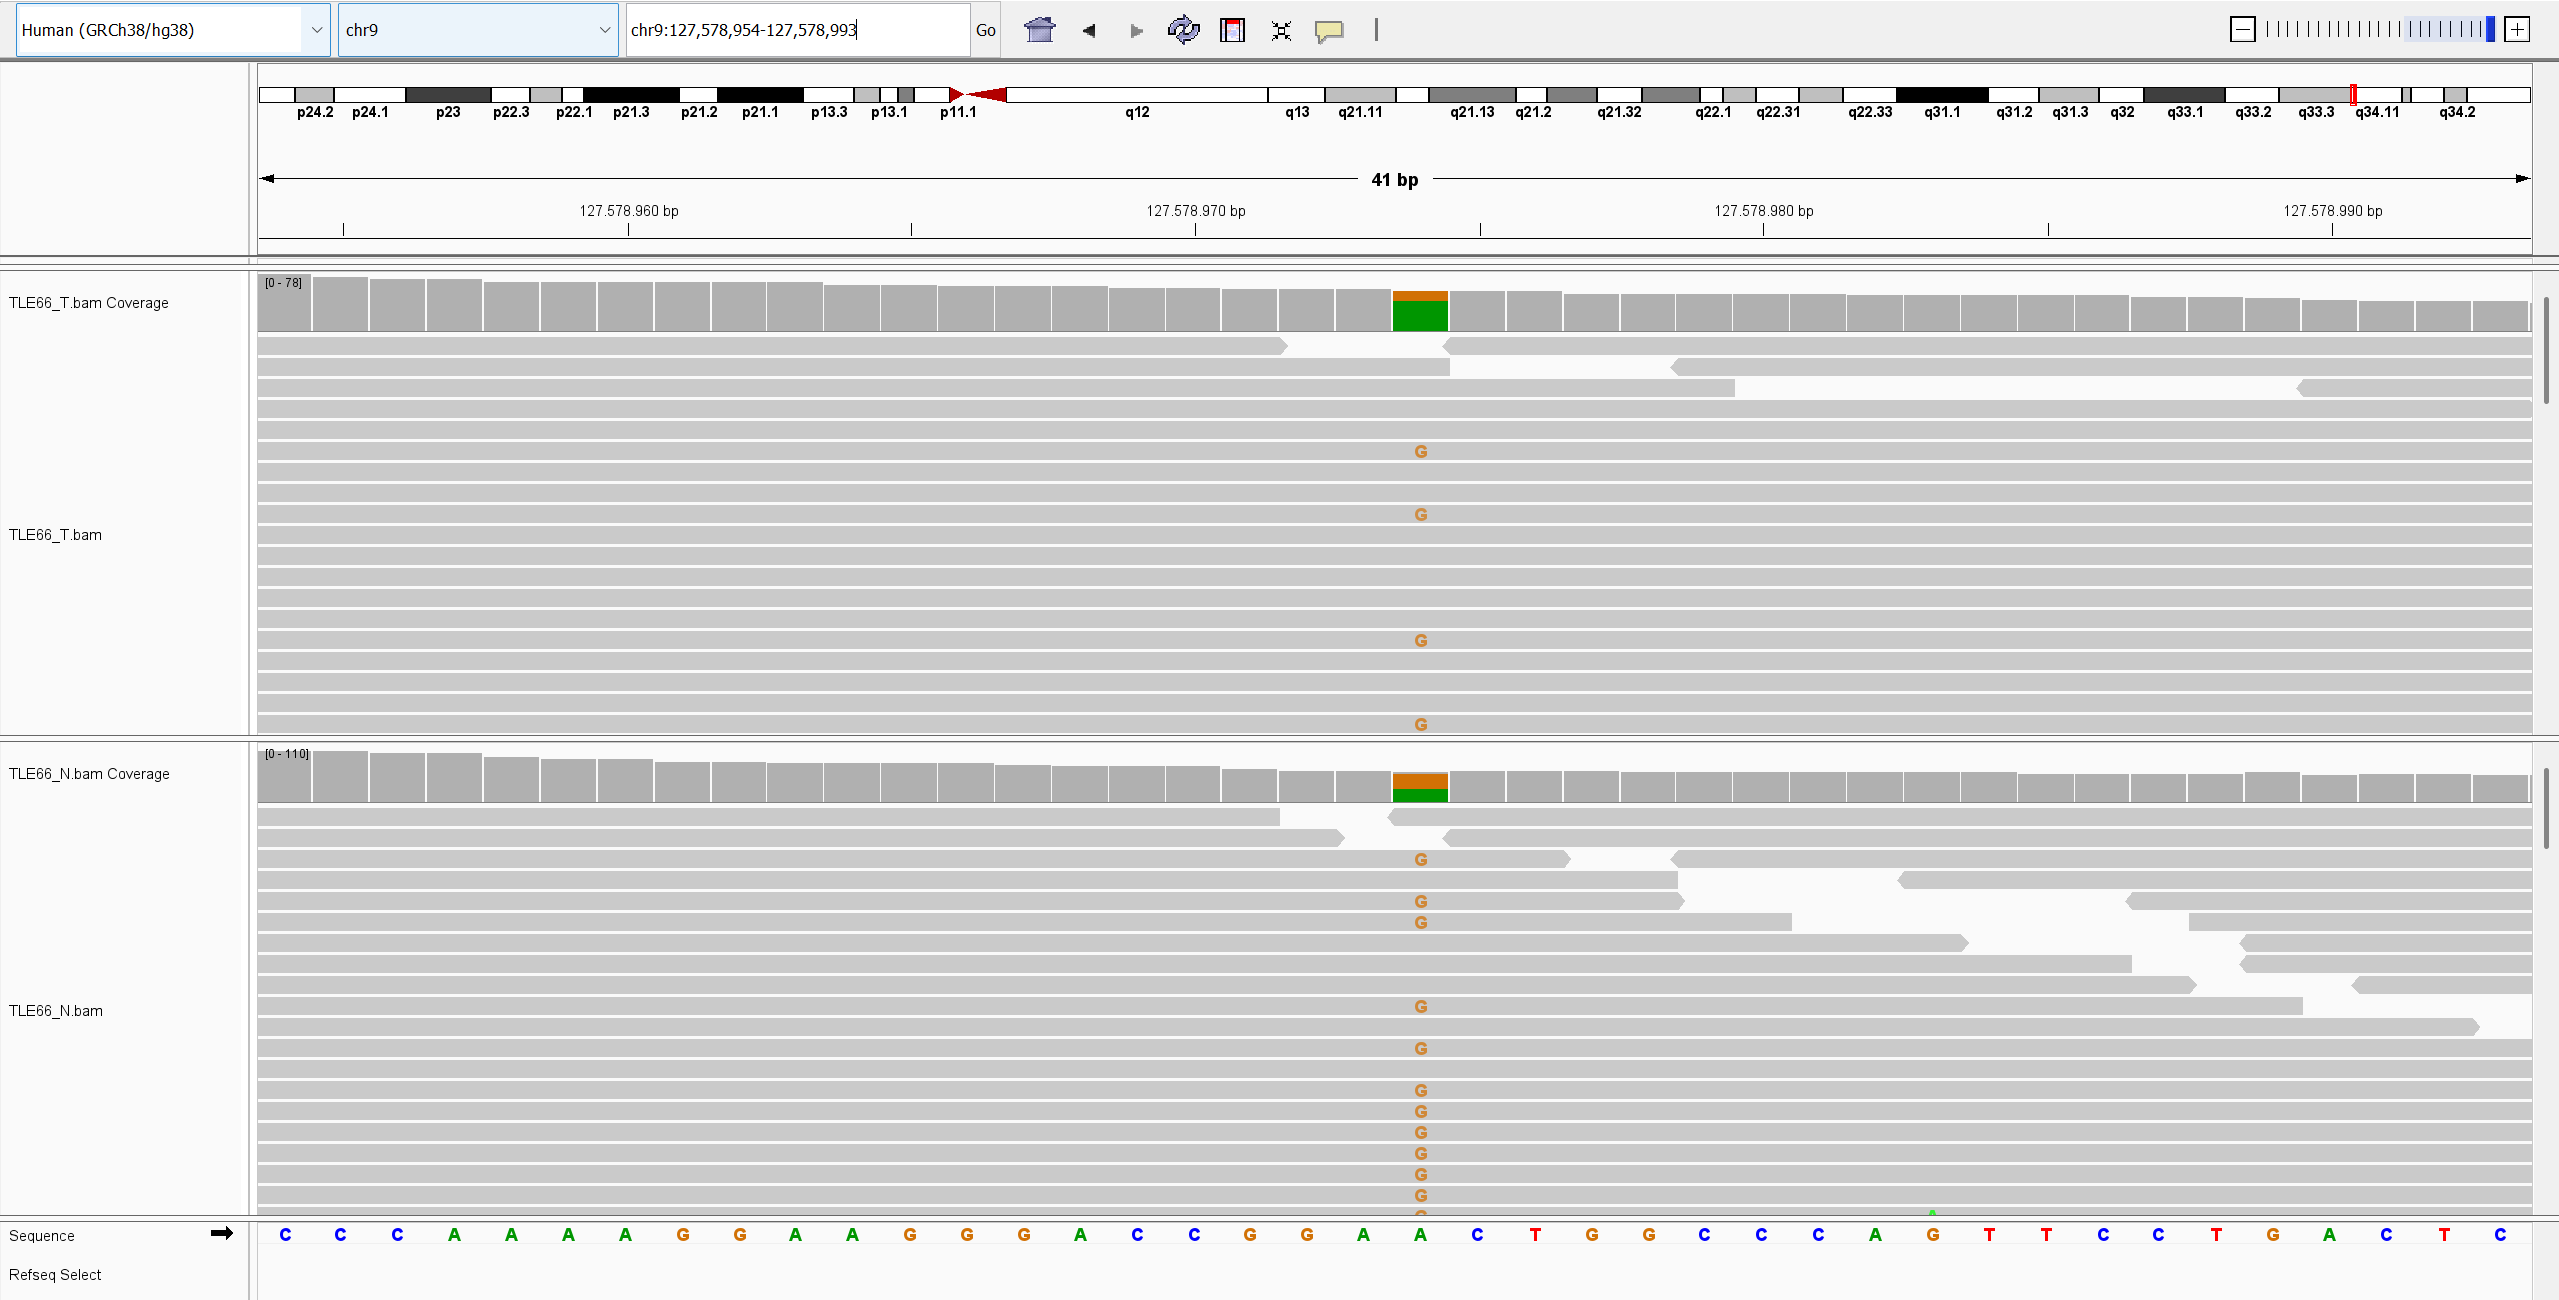 
* chr9_127715316
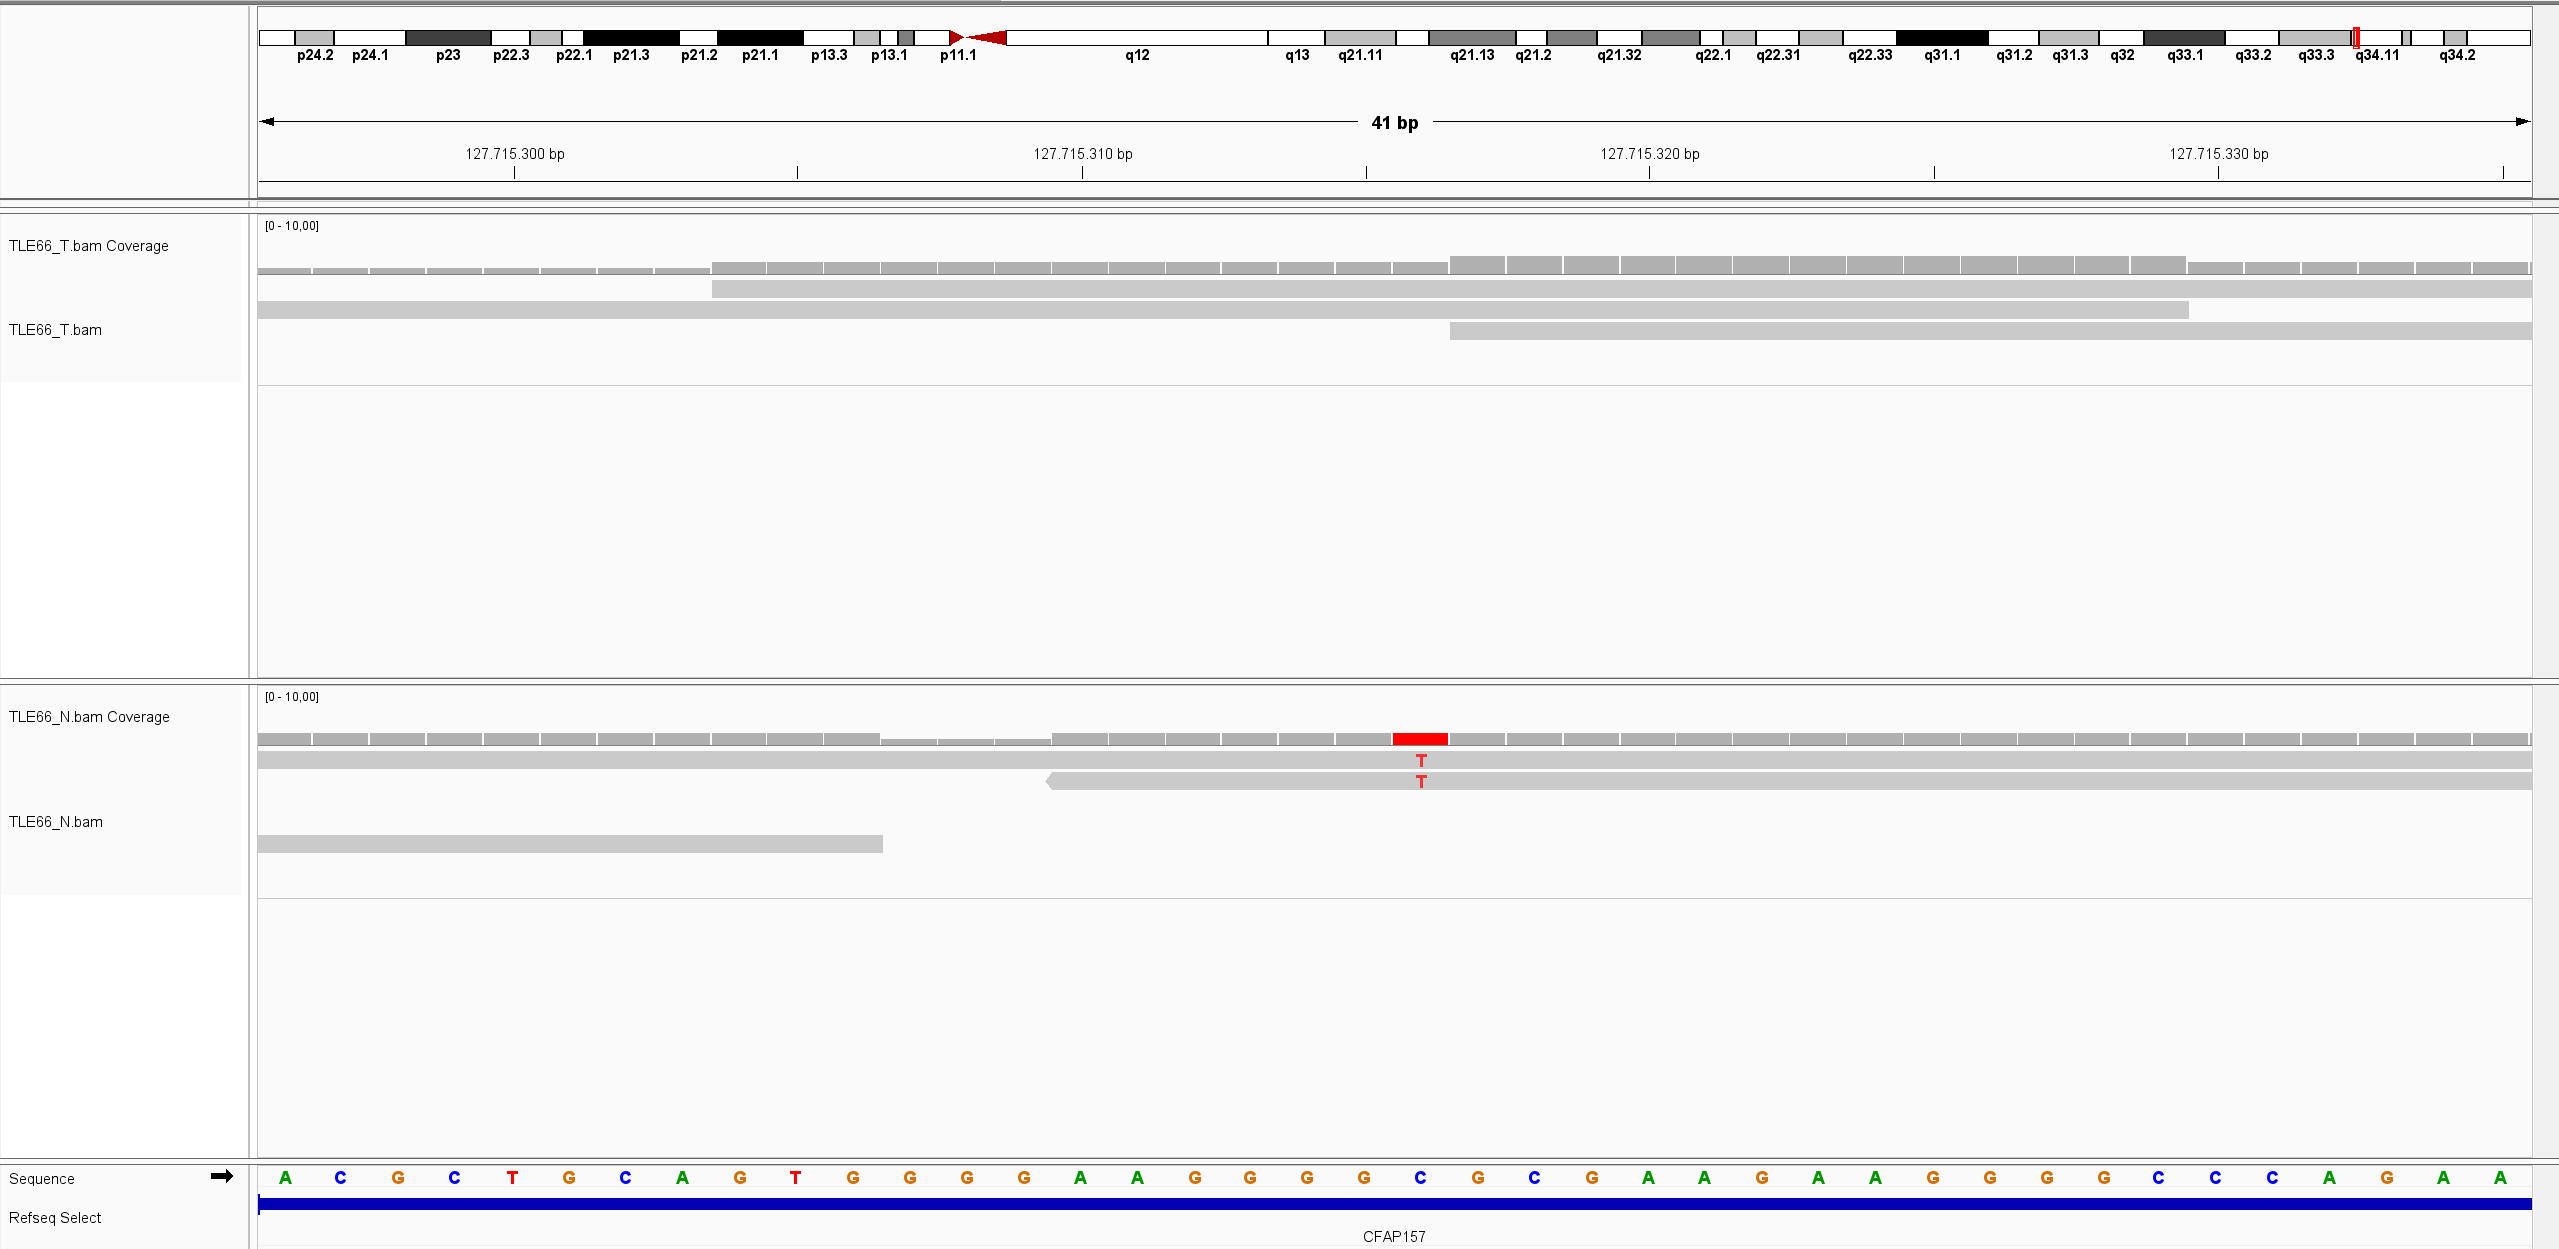
</div>

In [27]:
%%bash
echo "--- FILE STRUCTURE CHECK ---"
# Print the first 10 lines (header) and the last 3 lines (data)
head -n 10 clean_snps.vcf
echo "..."
tail -n 3 clean_snps.vcf

echo -e "\n--- FIND HIGH QUALITY SNP ---"
# Sorts by column 6 (QUAL) in reverse numeric order, prints top 3
awk -F'\t' '!/^#/ {print "Pos: "$2, "| Ref: "$4, "| Alt: "$5, "| Qual: "$6}' clean_snps.vcf | sort -k6,6nr | head -n 3

echo -e "\n--- FIND DIFFERENT VARIANTS (TUMOR vs NORMAL) ---"
# Compares the genotype (GT) field (e.g., 0/0 vs 0/1) between sample 1 (col 10) and sample 2 (col 11)
awk -F'\t' '!/^#/ { 
    gt1=substr($10,1,3); 
    gt2=substr($11,1,3); 
    if(gt1 != gt2) print "Pos: "$2, "| Ref: "$4, "| Alt: "$5, "| Normal: "gt1, "| Tumor: "gt2 
}' clean_snps.vcf | head -n 3

--- FILE STRUCTURE CHECK ---
##fileformat=VCFv4.2
##FILTER=<ID=PASS,Description="All filters passed">
##bcftoolsVersion=1.23+htslib-1.23
##bcftoolsCommand=mpileup -Ou -f /staging/leuven/stg_00079/teaching/hg38_9/chr9.fa TLE66_N.bam TLE66_T.bam
##reference=file:///staging/leuven/stg_00079/teaching/hg38_9/chr9.fa
##contig=<ID=chr9,length=138394717>
##ALT=<ID=*,Description="Represents allele(s) other than observed.">
##INFO=<ID=INDEL,Number=0,Type=Flag,Description="Indicates that the variant is an INDEL.">
##INFO=<ID=IDV,Number=1,Type=Integer,Description="Maximum number of raw reads supporting an indel">
##INFO=<ID=IMF,Number=1,Type=Float,Description="Maximum fraction of raw reads supporting an indel">
...
chr9	138243732	.	A	G	145.826	.	DP=29;VDB=0.683888;SGB=-4.72235;RPBZ=-0.235789;MQBZ=0;MQSBZ=0;BQBZ=-0.316431;SCBZ=0.590389;MQ0F=0;AC=2;AN=4;DP4=5,15,1,8;MQ=60	GT:PL:AD	0/1:91,0,174:8,5	0/1:89,0,222:12,4
chr9	138249280	.	G	C	125.856	.	DP=24;VDB=0.0967644;SGB=-4.10598;RPBZ=2.92979;MQBZ=0;B

In [28]:
%%bash
grep -v '#' raw_snps.vcf | head -2

chr9	34082802	.	C	T	13.2571	.	DP=2;VDB=0.02;SGB=0.0985265;MQ0F=0;AC=2;AN=2;DP4=0,0,0,2;MQ=22	GT:PL:AD	./.:0,0,0:0,0	1/1:40,6,0:0,2
chr9	34082803	.	A	G	13.2571	.	DP=2;VDB=0.02;SGB=0.0985265;MQ0F=0;AC=2;AN=2;DP4=0,0,0,2;MQ=22	GT:PL:AD	./.:0,0,0:0,0	1/1:40,6,0:0,2


Not all SNPs are equaly convincing

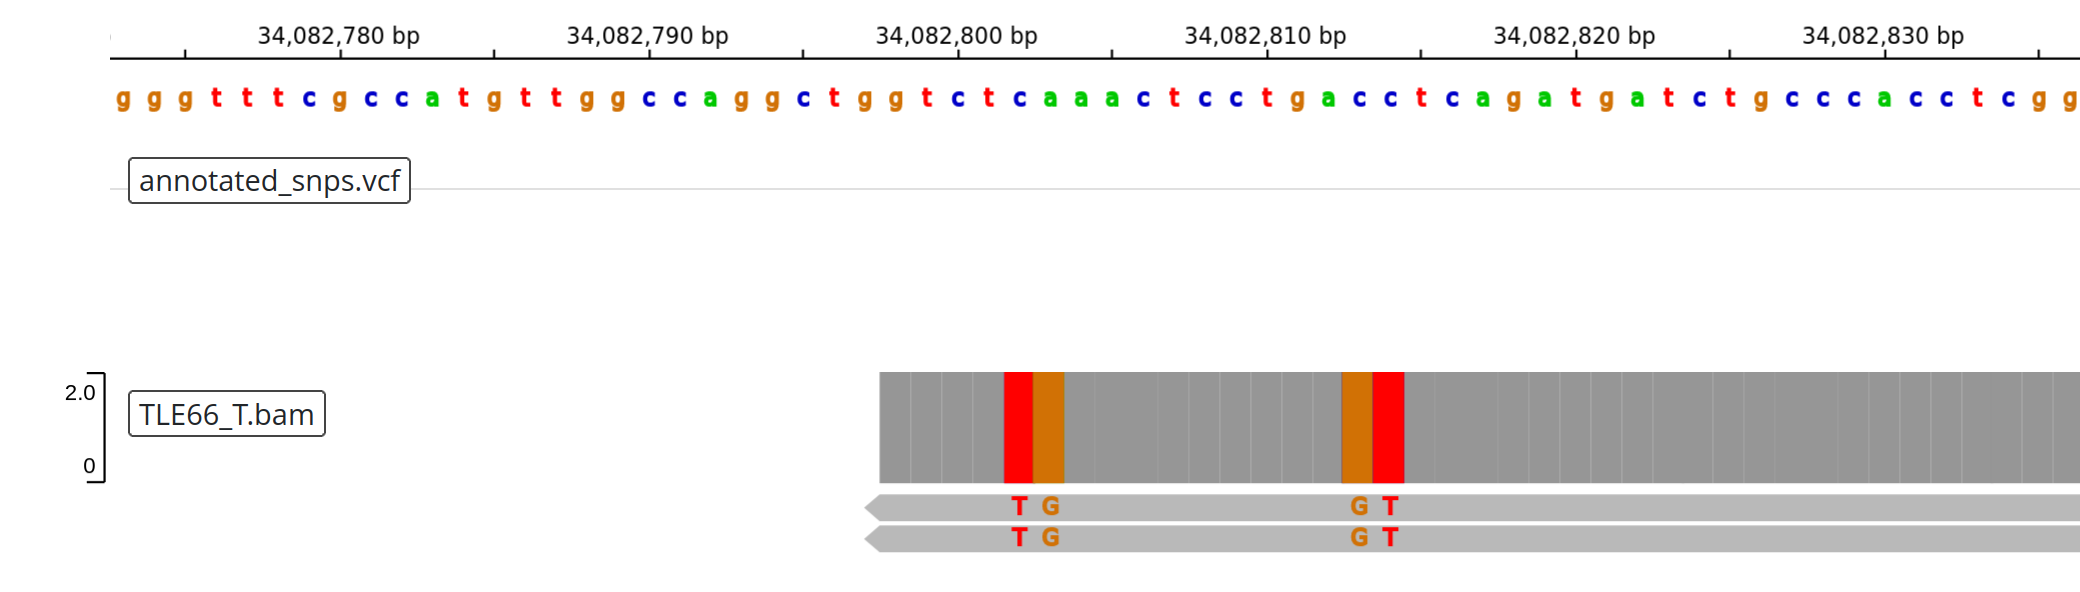

## SNP filtering & cleaning using `vt`

This is a VCF preprocessing pipeline that cleans up raw SNP calls before any downstream analysis. Each step fixes a specific class of problem:

* `vt decompose` splits multi-allelic variants (where multiple alternate alleles are listed on a single line) into separate biallelic records. Most tools downstream expect one variant per line, and PRS methods in particular are built around biallelic SNPs.
* `vt normalize -n -r $DB` left-aligns and normalizes indels against the reference genome. The same variant can be represented in multiple valid ways in VCF format — normalization ensures you have one canonical representation, which is critical when matching variants across datasets (e.g., GWAS summary statistics vs. your genotype calls).
* `vt uniq` removes exact duplicate records that may have arisen after decomposition and normalization — two originally different representations that are now identical.
* `vt view -f "QUAL>20"` filters out low-confidence variant calls. QUAL<20 corresponds roughly to less than 99% confidence that the variant is real, so you're dropping the noisiest calls.


In [29]:
%%bash
DB="/staging/leuven/stg_00079/teaching/hg38_9/chr9.fa"
cat raw_snps.vcf \
    | vt decompose - \
    | vt normalize -n -r $DB - \
    | vt uniq - \
    | vt view -f "QUAL>20" -h - \
    > clean_snps.vcf

uniq v0.57decompose v

options:     input VCF file        0.5-


         [o] output VCF file       options:     input VCF file        --

         [s] smart decomposition   false (experimental)
         [o] output VCF file       -

normalize v0.5

options:     input VCF file                                  -
         [o] output VCF file                                 -
         [w] sorting window size                             10000
         [n] no fail on reference inconsistency for non SNPs true
         [q] quiet                                           false
         [d] debug                                           false
         [r] reference FASTA file                            /staging/leuven/stg_00079/teaching/hg38_9/chr9.fa


stats: no. variants                 : 6661
       no. biallelic variants       : 6659
       no. multiallelic variants    : 2

       no. additional biallelics    : 2
       total no. of biallelics      : 6663

Time elapsed: 0.03s


stats: biall


<div style="background-color: khaki; padding: 10px;">

## Quality control

* Did all tools finish without error?
* Yes, the vt preprocessing tools and the bash evaluation script finished successfully without any errors.
* Is the file structure correct? (no lines, start, end, header, etc)
* Yes, the structure is perfectly intact. The file still starts with the required meta-information lines (e.g., ##fileformat=VCFv4.2), the column header row, and properly tab-delimited data rows. The tools successfully modified the data without breaking the VCF standard.
* Find a high quality SNP (awk, sort, excel, whatever you like). Discuss the criteria.
* A high-quality SNP was found at coordinate chr9:127578974 with a QUAL score of 422.738.
Criteria: Because this file was filtered using vt view -f "QUAL>20", we know every variant here has at least 99% confidence. By sorting the remaining variants by their QUAL score in reverse numeric order, we found this variant, which is exceptionally high quality and guaranteed to be a true biological mutation rather than noise.
* Attempt to find a variants that are different between the two samples (awk?). Check in IGV, copy/paste screenshot.
* A variant that differs between the tissues was found at coordinate chr9:127715316. The Normal sample is homozygous for the alternate allele (1/1), whereas the Tumor sample is homozygous for the reference allele (0/0).
* Visualize the above SNP in IGV, copy/paste a screenshot.
* 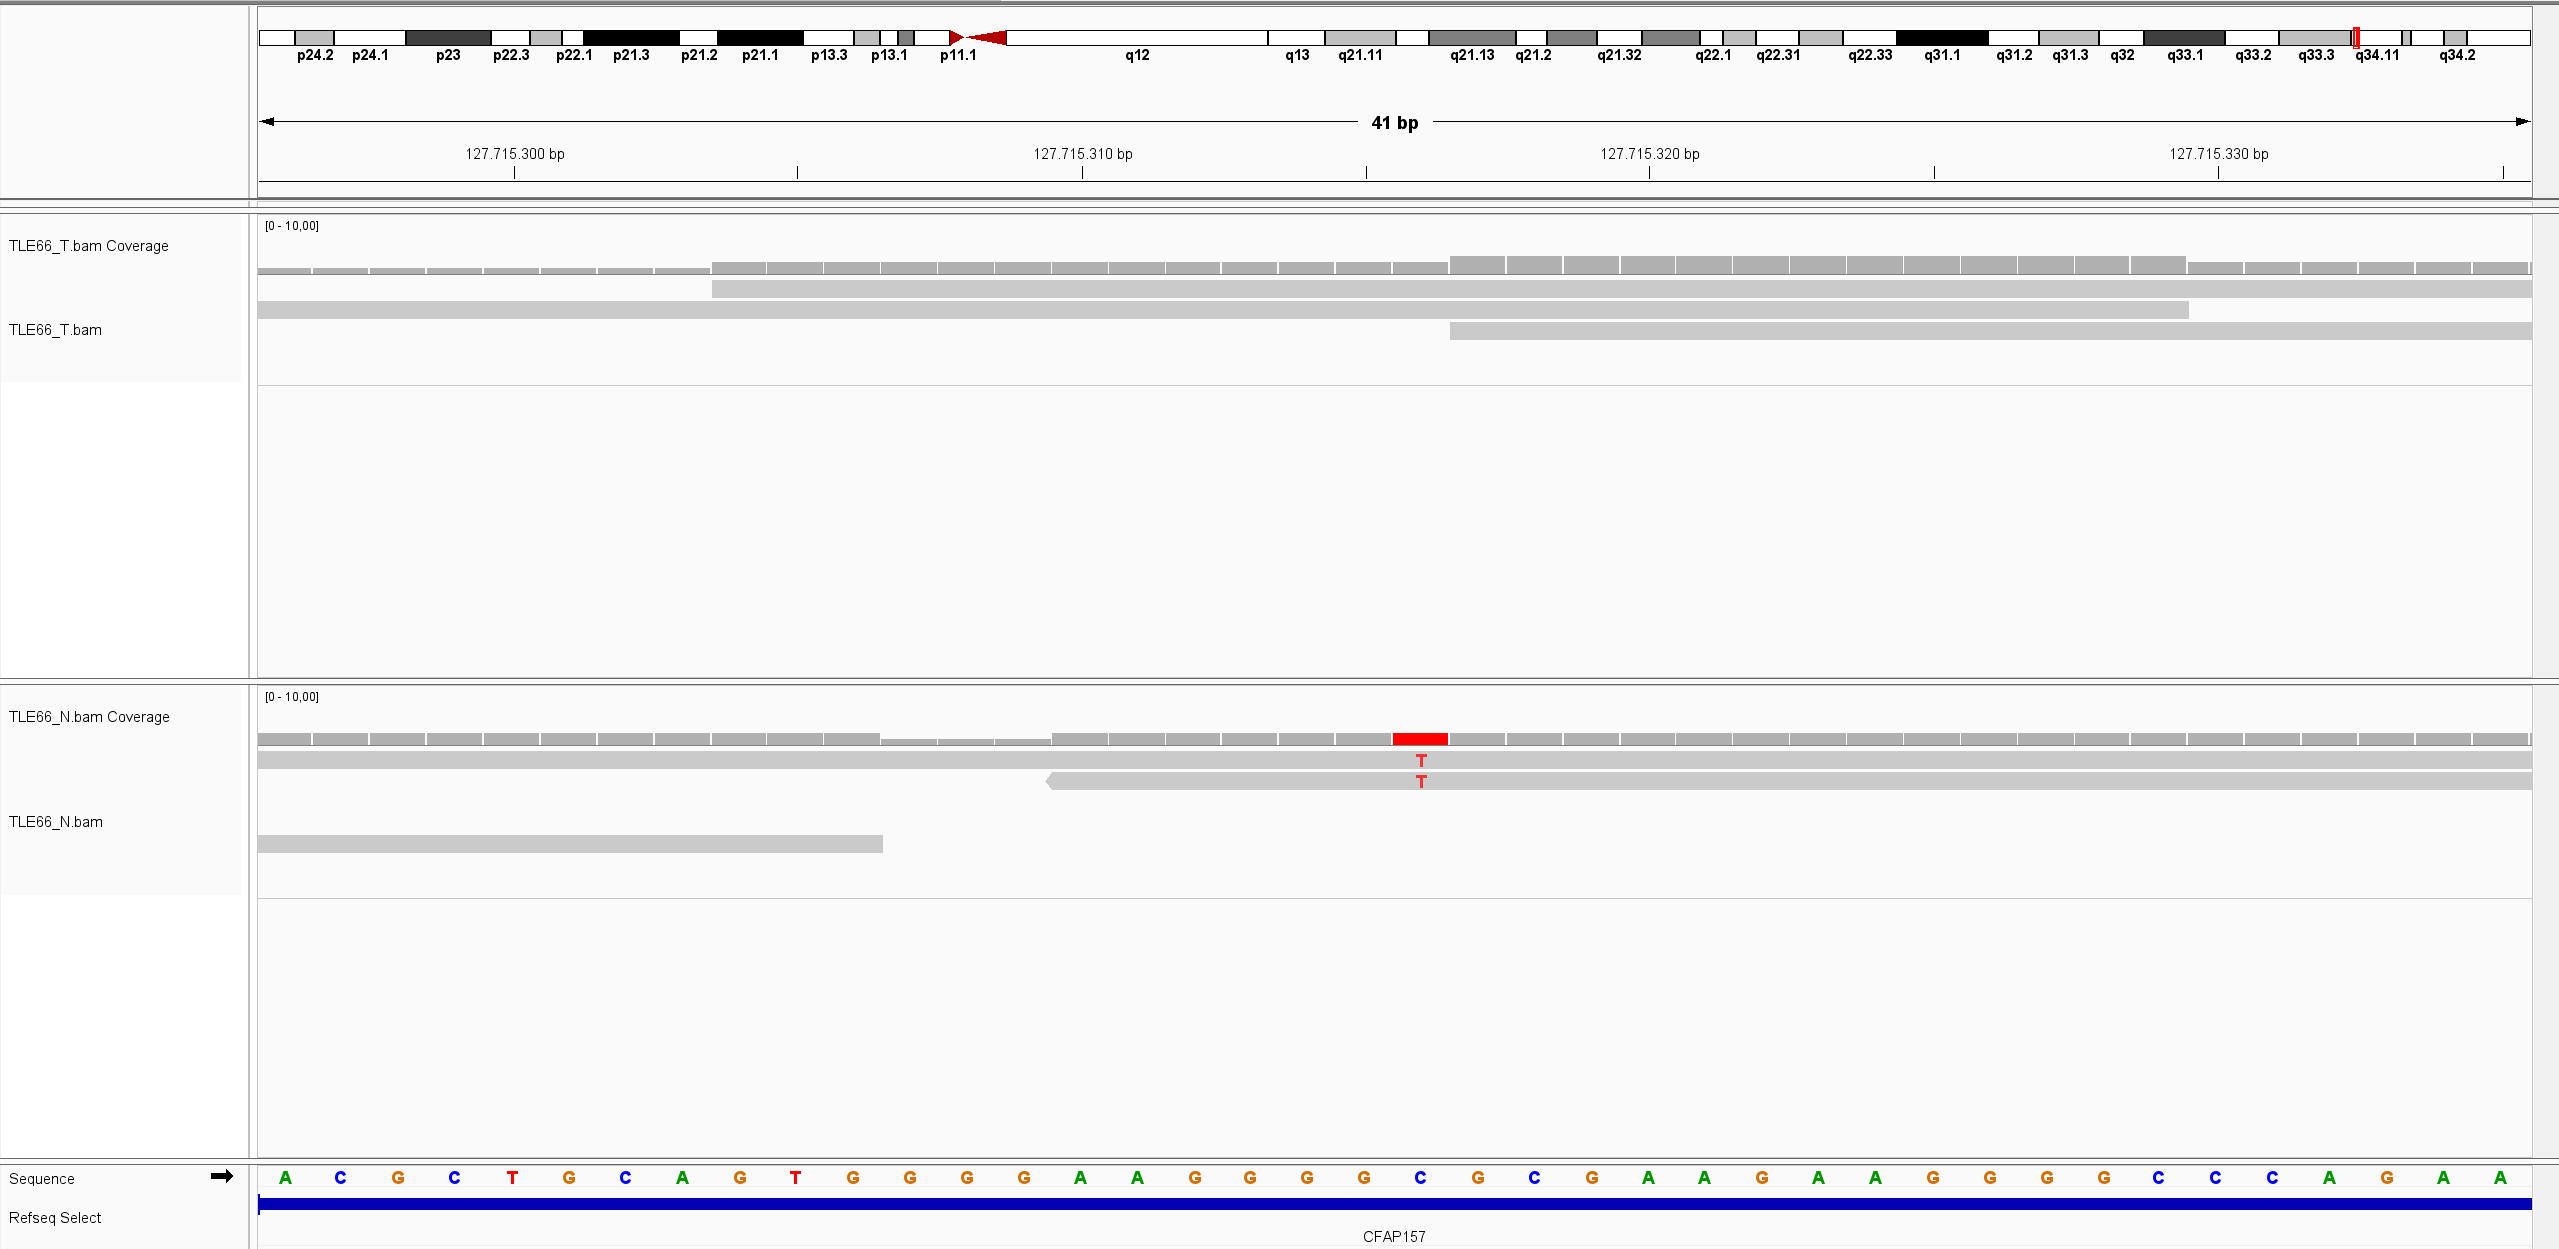 
* 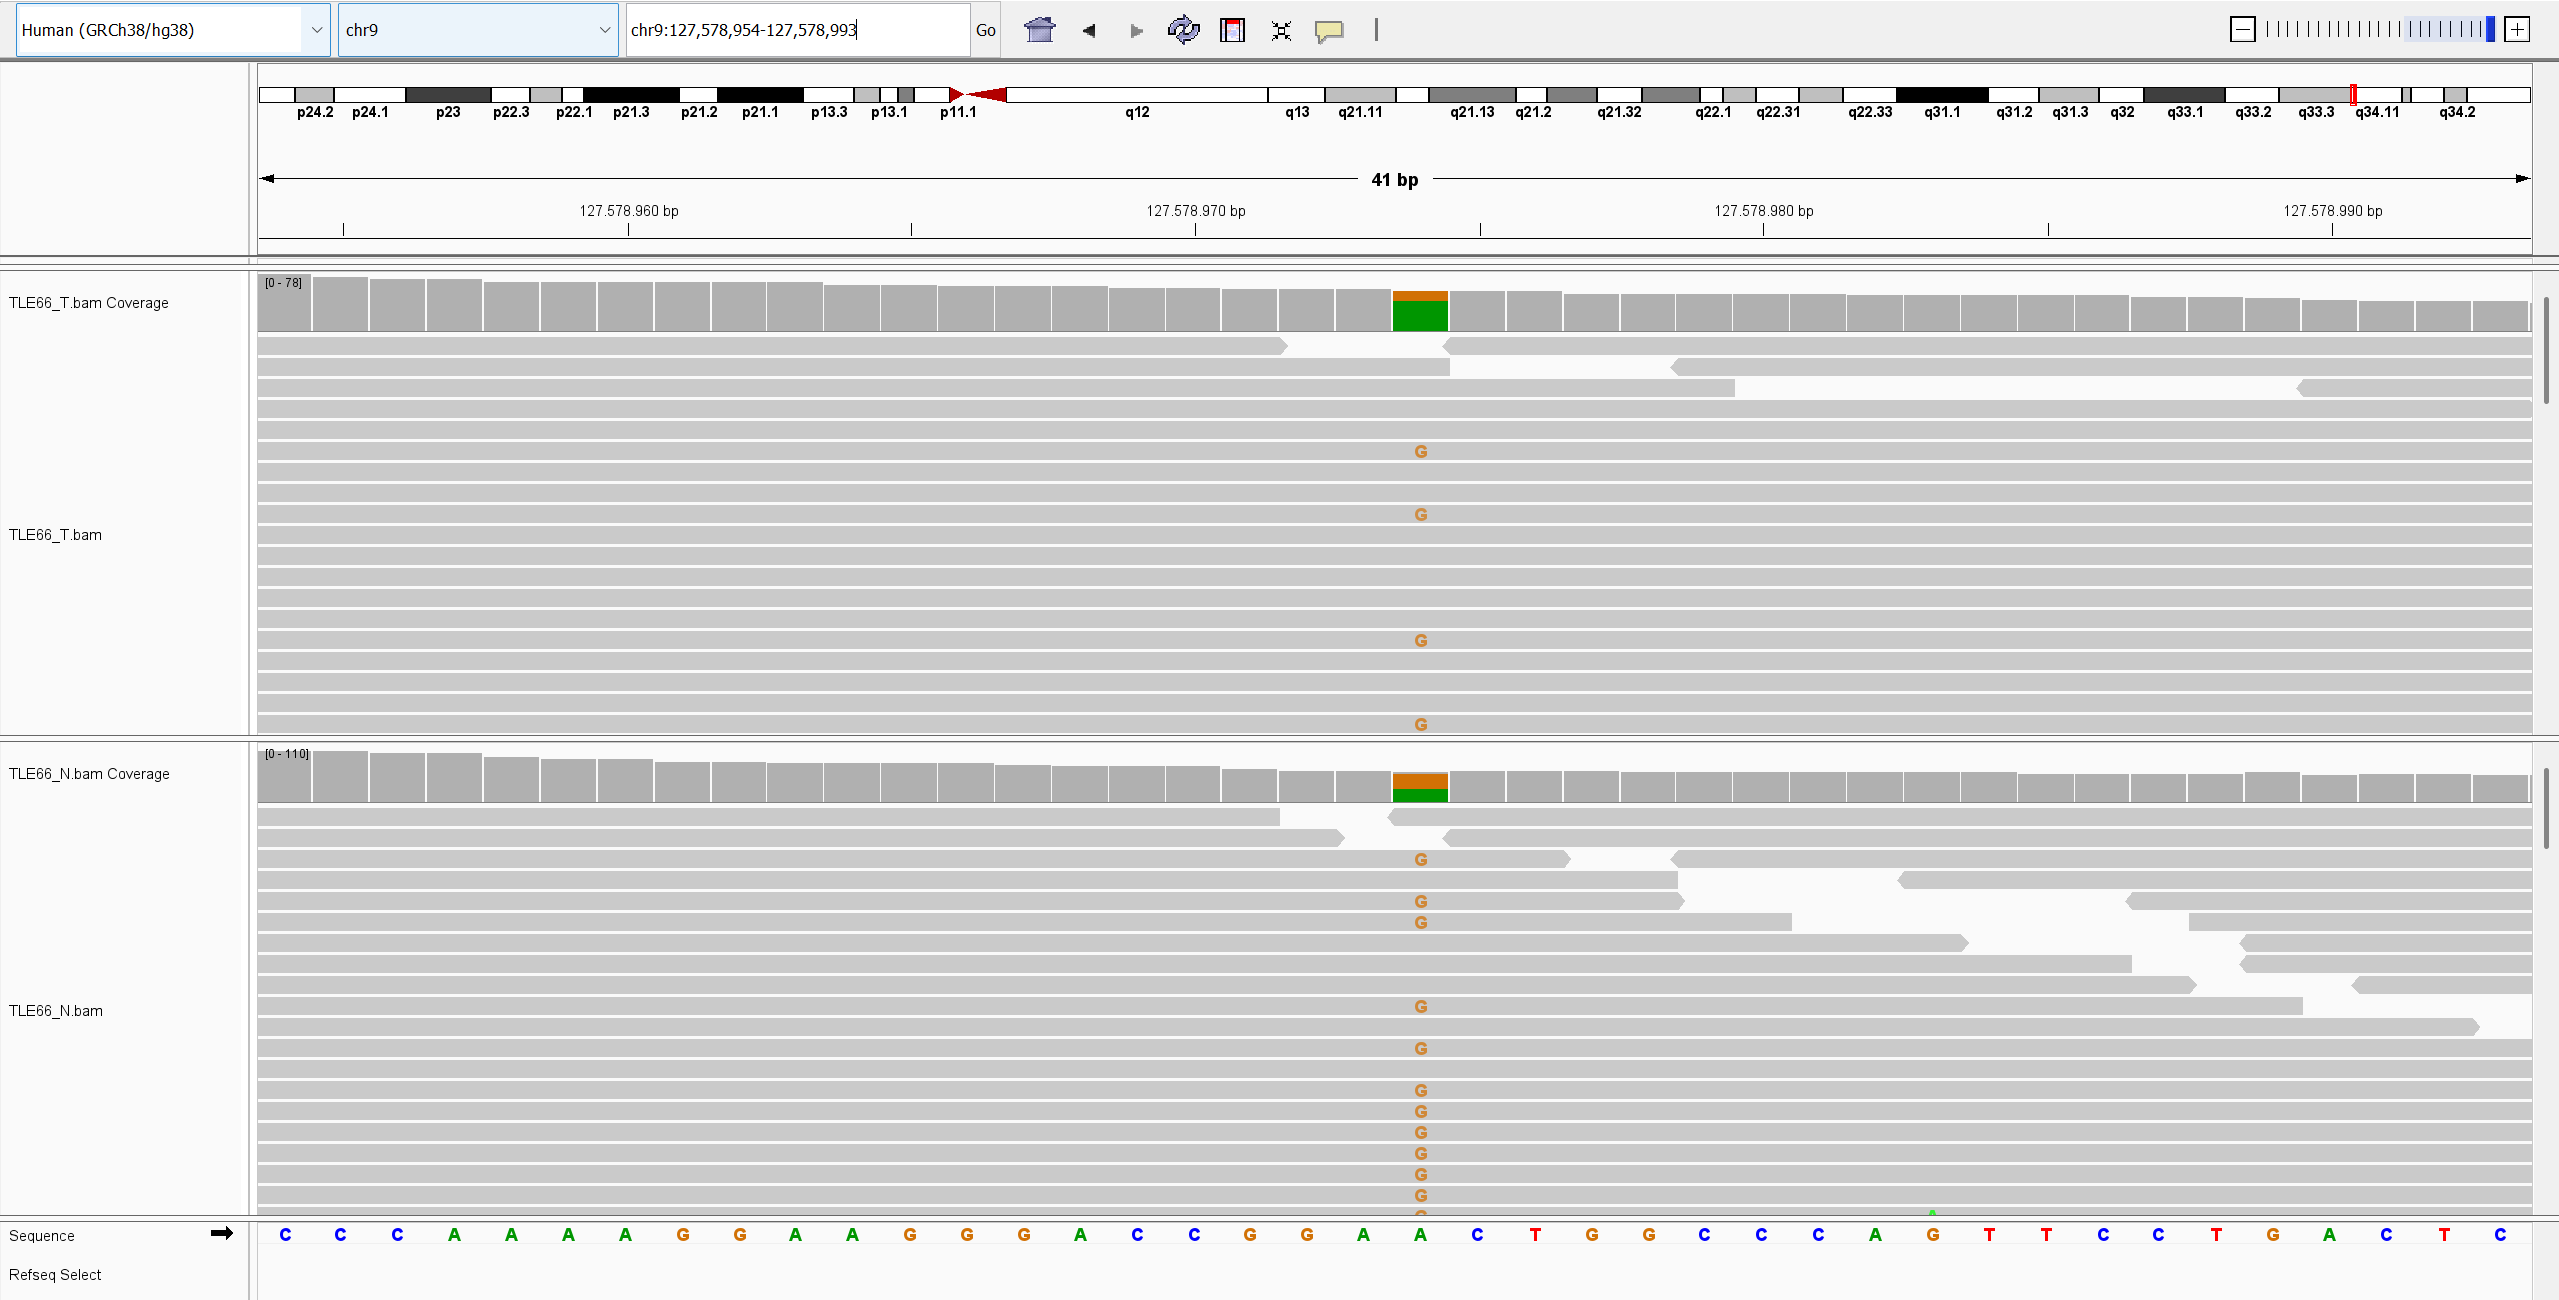

</div>



In [30]:
%%bash
VCF="clean_snps.vcf" # CHANGE THIS if your vt output file has a different name!

echo "--- FILE STRUCTURE CHECK ---"
head -n 10 $VCF
echo "..."
tail -n 3 $VCF

echo -e "\n--- FIND HIGH QUALITY SNP ---"
awk -F'\t' '!/^#/ {print "Pos: "$2, "| Ref: "$4, "| Alt: "$5, "| Qual: "$6}' $VCF | sort -k6,6nr | head -n 3

echo -e "\n--- FIND DIFFERENT VARIANTS (TUMOR vs NORMAL) ---"
awk -F'\t' '!/^#/ { 
    gt1=substr($10,1,3); 
    gt2=substr($11,1,3); 
    if(gt1 != gt2) print "Pos: "$2, "| Ref: "$4, "| Alt: "$5, "| Normal: "gt1, "| Tumor: "gt2 
}' $VCF | head -n 3

--- FILE STRUCTURE CHECK ---
##fileformat=VCFv4.2
##FILTER=<ID=PASS,Description="All filters passed">
##bcftoolsVersion=1.23+htslib-1.23
##bcftoolsCommand=mpileup -Ou -f /staging/leuven/stg_00079/teaching/hg38_9/chr9.fa TLE66_N.bam TLE66_T.bam
##reference=file:///staging/leuven/stg_00079/teaching/hg38_9/chr9.fa
##contig=<ID=chr9,length=138394717>
##ALT=<ID=*,Description="Represents allele(s) other than observed.">
##INFO=<ID=INDEL,Number=0,Type=Flag,Description="Indicates that the variant is an INDEL.">
##INFO=<ID=IDV,Number=1,Type=Integer,Description="Maximum number of raw reads supporting an indel">
##INFO=<ID=IMF,Number=1,Type=Float,Description="Maximum fraction of raw reads supporting an indel">
...
chr9	138243732	.	A	G	145.826	.	DP=29;VDB=0.683888;SGB=-4.72235;RPBZ=-0.235789;MQBZ=0;MQSBZ=0;BQBZ=-0.316431;SCBZ=0.590389;MQ0F=0;AC=2;AN=4;DP4=5,15,1,8;MQ=60	GT:PL:AD	0/1:91,0,174:8,5	0/1:89,0,222:12,4
chr9	138249280	.	G	C	125.856	.	DP=24;VDB=0.0967644;SGB=-4.10598;RPBZ=2.92979;MQBZ=0;B

## Snp Annotation using SnpEff

In [31]:
%%bash
# get help using:
snpEff || true

Error        :	Missing genomer_version parameter
Command line :	SnpEff  

snpEff version SnpEff 5.4a (build 2025-11-25 12:22), by Pablo Cingolani
Usage: snpEff [ann] [options] genome_version [input_file]


	variants_file                   : Default is STDIN



Options:
	-chr <string>                   : Prepend 'string' to chromosome name (e.g. 'chr1' instead of '1'). Only on TXT output.
	-classic                        : Use old style annotations instead of Sequence Ontology and Hgvs.
	-csvStats <file>                : Create CSV summary file.
	-download                       : Download reference genome if not available. Default: true
	-i <format>                     : Input format [ vcf, bed ]. Default: VCF.
	-fileList                       : Input actually contains a list of files to process.
	-o <format>                     : Output format [ vcf, gatk, bed, bedAnn ]. Default: VCF.
	-s , -stats, -htmlStats         : Create HTML summary file.  Default is 'snpEff_summary.html'
	-noSta

In [32]:
%%bash
# sorry this is ugly - but to run snpEff - we need more memory
# I'm sure there is a more elegant way - but I could not find it..

SNPEFF_JAR="/lustre1/project/stg_00079/teaching/I0U19a_conda_2026/share/snpeff-5.4.0a-0/snpEff.jar"

java -Xmx3400m -jar ${SNPEFF_JAR} eff hg19 -dataDir /staging/leuven/stg_00079/teaching/snpeff_db \
        clean_snps.vcf > annotated_snps.vcf



NEW VERSION!
	There is a new SnpEff version available: 
		Version      : 5.4C
		Release date : 2026-02-23
		Download URL : https://snpeff-public.s3.amazonaws.com/versions/snpEff_latest_core.zip



<div style="background-color: khaki; padding: 10px;">

## snpEff Quality control

* Do you have annotations in the records? Show one HIGH impact one? 
* Yes, the records have been successfully annotated. The INFO column now contains the ANN= string with predictions from snpEff. Here is an example of a HIGH impact frameshift variant found in the PPP6C gene:

* chr9 127912188 . G GC 208.644 . INDEL;IDV=8;IMF=0.666667;DP=21;VDB=0.559446;SGB=-5.64361;RPBZ=0.0711362;MQBZ=0;BQBZ=-1.64721;SCBZ=0.866025;MQ0F=0;AC=2;AN=4;DP4=8,1,11,1;MQ=60;OLD_VARIANT=chr9:127912188:GCCCC/GCCCCC;ANN=GC|frameshift_variant|HIGH|PPP6C|PPP6C|transcript|NM_001123355.1|protein_coding|8/8|c.792_793insG|p.Asn265fs|1013/4350|792/1029|264/342||,GC|frameshift_variant|HIGH|PPP6C|PPP6C|transcript|NM_002721.5|protein_coding|7/7|c.681_682insG|p.Asn228fs|766/4103|681/918|227/305||,GC|frameshift_variant|HIGH|PPP6C|PPP6C|transcript|NM_001123369.1|protein_coding|6/6|c.615_616insG|p.Asn206fs|836/4173|615/852|205/283||;LOF=(PPP6C|PPP6C|3|1.00) GT:PL:AD 0/1:159,0,75:4,8 0/1:83,0,75:5,4
* Can you think of other (simple) controls for a snpEff annotated vcf file?

* 1. Variant Counts: Run wc -l on both the clean VCF and the annotated VCF. The number of variants should be exactly identical to ensure no data was dropped during annotation.
* 2. Reference Genome Matching: Verify in the VCF header (grep "^##" annotated_snps.vcf) that the snpEff database used (e.g., hg38 or hg19) exactly matches the genome used for the BWA alignment. A mismatch will result in completely false annotations.
* 2. Summary Report Metrics: Check the snpEff_summary.html file to ensure biological metrics are plausible, such as a Transition/Transversion (Ts/Tv) ratio of roughly ~2.0 for human exomes.

</div>


In [33]:
%%bash
grep -v "^#" annotated_snps.vcf | grep "HIGH" | head -n 1

chr9	127912188	.	G	GC	208.644	.	INDEL;IDV=8;IMF=0.666667;DP=21;VDB=0.559446;SGB=-5.64361;RPBZ=0.0711362;MQBZ=0;BQBZ=-1.64721;SCBZ=0.866025;MQ0F=0;AC=2;AN=4;DP4=8,1,11,1;MQ=60;OLD_VARIANT=chr9:127912188:GCCCC/GCCCCC;ANN=GC|frameshift_variant|HIGH|PPP6C|PPP6C|transcript|NM_001123355.1|protein_coding|8/8|c.792_793insG|p.Asn265fs|1013/4350|792/1029|264/342||,GC|frameshift_variant|HIGH|PPP6C|PPP6C|transcript|NM_002721.5|protein_coding|7/7|c.681_682insG|p.Asn228fs|766/4103|681/918|227/305||,GC|frameshift_variant|HIGH|PPP6C|PPP6C|transcript|NM_001123369.1|protein_coding|6/6|c.615_616insG|p.Asn206fs|836/4173|615/852|205/283||;LOF=(PPP6C|PPP6C|3|1.00)	GT:PL:AD	0/1:159,0,75:4,8	0/1:83,0,75:5,4
